In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import metrics, model_selection, linear_model

import tensorflow as tf
from tensorflow import keras


2026-01-07 07:02:29.308364: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767769349.321736      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767769349.325794      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-07 07:02:29.343556: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
def laplace_likelihood(y, p):
    m, s = p
    diff = np.minimum(1000, np.abs(y - m))
    s = np.maximum(70, s)
    lik = -np.sqrt(2) * diff / s - np.log(np.sqrt(2) * s)
    return np.mean(lik)


def laplace_likelihood_bound(y, p):
    m = p
    diff = np.minimum(1000, np.abs(y - m))
    s = np.maximum(70, np.sqrt(2) * diff)
    lik = -np.sqrt(2) * diff / s - np.log(np.sqrt(2) * s)
    return np.mean(lik)


def laplace_likelihood_avg(y, p):
    m = p
    diff = np.minimum(1000, np.abs(y - m))
    s = np.sqrt(2) * metrics.mean_absolute_error(y, m)
    lik = -np.sqrt(2) * diff / s - np.log(np.sqrt(2) * s)
    return np.mean(lik)


In [3]:
def build_folds(X, y, group=None, k=5, shuffle=False, train_mask=None, valid_mask=None):
    if isinstance(X, pd.DataFrame): X = X.values
    if isinstance(y, pd.DataFrame): y = y.values
    if isinstance(group, pd.DataFrame): group = group.values
    if isinstance(train_mask, pd.DataFrame): train_mask = train_mask.values
    if isinstance(valid_mask, pd.DataFrame): valid_mask = valid_mask.values
    if group is None:
        folds = list(model_selection.KFold(k, shuffle=True).split(X, y))
    else:
        idx = utils.shuffle(np.arange(X.shape[0]))
        if shuffle:
            Xs, ys, groups = X.copy()[idx], y.copy()[idx], group.copy()[idx]
            folds = list(model_selection.GroupKFold(k).split(np.array(Xs), np.array(ys), np.array(groups)))
        else:
            folds = list(model_selection.GroupKFold(k).split(X, y, group))
    if train_mask is not None:
        for i in range(k):
            folds[i] = (np.array([j for j in folds[i][0] if train_mask[j]]), folds[i][1])
    if valid_mask is not None:
        for i in range(k):
            folds[i] = (folds[i][0], np.array([j for j in folds[i][1] if valid_mask[j]]))
    return folds


In [4]:
def feature_eng(df):
    df = df.copy()
    df['n_weeks'] = df['Weeks_target'] - df['Weeks_base']
    df['Sex_female'] = (df['Sex'] == 'Female').astype('float')
    df['Smoking_ex'] = (df['SmokingStatus'] == 'Ex-smoker').astype(int)
    df['Smoking_currently'] = (df['SmokingStatus'] == 'Currently smokes').astype(int)
    return df


In [5]:
data_folder = "../input/osic-pulmonary-fibrosis-progression"


In [6]:
df_train = pd.read_csv(os.path.join(data_folder, "train.csv")).drop_duplicates(keep=False, subset=['Patient', 'Weeks'])

df_train['n_obs'] = df_train.groupby('Patient').Weeks.cumcount()
df_train['till_last'] = df_train.groupby('Patient').Weeks.transform('count') - 1 - df_train['n_obs']

df_train = df_train.merge(df_train.drop(['Age', 'Sex', 'Percent', 'SmokingStatus'], 1), on='Patient', suffixes=['_base', '_target'])

df_train = feature_eng(df_train)
FEATURES = ['n_weeks', 'FVC_base', 'Percent', 'Age', 'Sex_female', 'Smoking_ex', 'Smoking_currently']

df_train.head(2)


TypeError: DataFrame.drop() takes from 1 to 2 positional arguments but 3 were given

In [7]:
train_mask = (df_train.n_weeks > 0) & df_train.n_obs_base.between(0, 0) & df_train.till_last_target.between(0, 100)
valid_mask = (df_train.n_weeks > 0) & df_train.n_obs_base.between(0, 0) & df_train.till_last_target.between(0, 2)


AttributeError: 'DataFrame' object has no attribute 'n_weeks'

In [8]:
df_test = pd.read_csv(os.path.join(data_folder, "test.csv")).rename(columns={'Weeks': 'Weeks_base', 'FVC': 'FVC_base'})
df_test = df_test.assign(k=0).merge(pd.DataFrame({'Weeks_target': np.arange(-12, 133 + 1), 'k': 0})).drop('k', 1)
df_test = feature_eng(df_test)

df_test.head(2)


TypeError: DataFrame.drop() takes from 1 to 2 positional arguments but 3 were given

In [9]:
print(100 * "#")
print("Train: %4d rows with %3d unique patients" % (df_train[train_mask].shape[0], df_train[train_mask].Patient.nunique()))
print("Valid: %4d rows with %3d unique patients" % (df_train[valid_mask].shape[0], df_train[valid_mask].Patient.nunique()))
print("Test:  %4d rows with %3d unique patients" % (df_test.shape[0], df_test.Patient.nunique()))
print(100 * "#")


####################################################################################################


NameError: name 'train_mask' is not defined

In [10]:
X = df_train[FEATURES].copy()
y = df_train['FVC_target'].copy()
X_test = df_test[FEATURES].copy()


NameError: name 'FEATURES' is not defined

In [11]:
model = linear_model.LinearRegression()
model.fit(X[train_mask], y[train_mask])
pred_mean = model.predict(X)
test_mean = model.predict(X_test)


NameError: name 'X' is not defined

In [12]:
opt_sigma = np.sqrt(2) * np.clip(np.abs(y - pred_mean), 0, 1000)
plt.hist(opt_sigma, 50);


NameError: name 'y' is not defined

In [13]:
model = linear_model.LinearRegression()
model.fit(X[train_mask], opt_sigma[train_mask])
pred_sigma = model.predict(X)
test_sigma = model.predict(X_test)


NameError: name 'X' is not defined

NameError: name 'y' is not defined

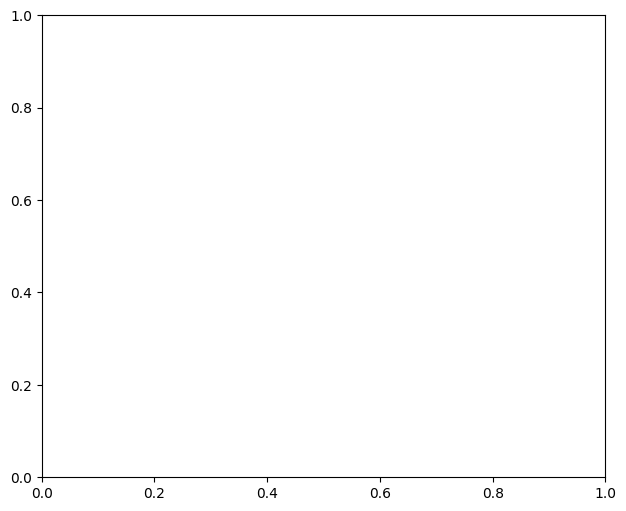

In [14]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.scatter(y[valid_mask], pred_mean[valid_mask], alpha=0.2);
plt.xlim(min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1]))
plt.ylim(min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1]))
plt.plot(plt.xlim(), plt.ylim(), color='tab:red', alpha=0.5, linestyle='--')
plt.subplot(1, 2, 2)
plt.scatter(opt_sigma[valid_mask], pred_sigma[valid_mask], alpha=0.2)
plt.xlim(min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1]))
plt.ylim(min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1]))
plt.plot(plt.xlim(), plt.ylim(), color='tab:red', alpha=0.5, linestyle='--');


In [15]:
plt.figure(figsize=(16, 8))
for i, pid in enumerate(df_train[valid_mask].Patient.unique()[:12]):
    plt.subplot(3, 4, i + 1)
    idx = (df_train.Patient == pid) & (df_train.n_obs_base == 0)
    plt.fill_between(
        df_train[idx].Weeks_target,
        pred_mean[idx] - 1 * pred_sigma[idx],
        pred_mean[idx] + 1 * pred_sigma[idx],
        color='tab:blue', alpha=0.1
    )
    plt.fill_between(
        df_train[idx].Weeks_target,
        pred_mean[idx] - 2 * pred_sigma[idx],
        pred_mean[idx] + 2 * pred_sigma[idx],
        color='tab:blue', alpha=0.1
    )
    plt.plot(df_train[idx].Weeks_target, pred_mean[idx], marker='x', color='tab:blue')
    plt.plot(df_train[idx].Weeks_target, df_train[idx].FVC_target, marker='o', color='tab:red')


NameError: name 'valid_mask' is not defined

<Figure size 1600x800 with 0 Axes>

In [16]:
submission = df_test.copy()[['Patient', 'Weeks_target']]
submission['Patient_Week'] = submission['Patient'] + "_" + submission['Weeks_target'].astype('str')
submission['FVC'] = test_mean
submission['Confidence'] = test_sigma
submission = submission.sort_values(['Weeks_target', 'Patient'])[['Patient_Week', 'FVC', 'Confidence']]
submission.head()


KeyError: "['Weeks_target'] not in index"

In [17]:
submission.to_csv("submission.csv", index=False)


NameError: name 'submission' is not defined